# Stream Modeling with streamdf

galpy's `streamdf` class models tidal streams using action-angle coordinates.
The basic idea is that stream stars were stripped from a progenitor at different
times and therefore have slightly different orbital frequencies. Over time, this
frequency spread causes them to spread out along the orbit, forming a stream.
`streamdf` predicts the stream track on the sky, the density along the stream,
and allows sampling of stream stars.

In [1]:
%matplotlib inline
import numpy
import matplotlib.pyplot as plt
from galpy.df import streamdf
from galpy.orbit import Orbit
from galpy.potential import LogarithmicHaloPotential
from galpy.actionAngle import actionAngleIsochroneApprox
from galpy.util import conversion
from astropy import units
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

## Physical picture behind `streamdf`

`streamdf` is based on a simple action-angle picture of tidal stripping.
As an example, the movie below shows the disruption of a cluster on a GD-1-like
orbit around the Milky Way from [Bovy (2014)](http://adsabs.harvard.edu/abs/2014ApJ...795...95B).
The blue curve is the progenitor orbit and the black points are stripped stars.

<video width="600" height="400" controls>
  <source src="https://www.astro.utoronto.ca/~bovy/streams/gd1-sim-mp4/gd1_evol_orbplane_comov.mp4" type="video/mp4">
</video>

Once stars are stripped from the progenitor in a static host potential, their
actions are approximately conserved, but they have slightly different orbital
frequencies from the progenitor and from one another. Those small frequency
offsets accumulate into angle offsets that grow roughly linearly with time,
which is why the debris stretches into a long, thin stream. Because the debris
occupies a distribution in actions and frequencies, the stream track is in
general not the same as the progenitor orbit. The next movie shows the debris in
action space: stars in the stream settle onto nearly fixed actions once they are
stripped, while stars still bound to the cluster do not.

<video width="600" height="400" controls>
  <source src="https://www.astro.utoronto.ca/~bovy/streams/gd1-sim-mp4/gd1_evol_aai_jrjzlz_debris.mp4" type="video/mp4">
</video>

Angle offsets then grow approximately linearly with time, which is what stretches
the debris into a stream.

<video width="600" height="400" controls>
  <source src="https://www.astro.utoronto.ca/~bovy/streams/gd1-sim-mp4/gd1_evol_aai_arazap.mp4" type="video/mp4">
</video>

Finally, the frequency-angle structure along the stream explains why streams are
not exactly orbits: stars removed with larger frequency offsets run away faster,
so different parts of the stream trace slightly different effective orbits.

<video width="600" height="400" controls>
  <source src="https://www.astro.utoronto.ca/~bovy/streams/gd1-sim-mp4/gd1_evol_aai_oparapar.mp4" type="video/mp4">
</video>

Later in this notebook,
`freqEigvalRatio` measures how nearly one-dimensional the debris is,
`misalignment` measures how well the stream aligns with the progenitor
frequency direction, and `plotCompareTrackAAModel` checks that the computed
track is self-consistent in frequency-angle space.

## Initialize streamdf

We need three ingredients to initialize a `streamdf` instance:

1. A gravitational potential
2. An action-angle calculator for that potential
3. A progenitor orbit

As an example, we will use the a simple flattened logarithmic potential, the `actionAngleIsochroneApprox` method for computing actions, and a progenitor orbit with a pericenter of 14 kpc and an apocenter of 26 kpc.

In [2]:
lp = LogarithmicHaloPotential(normalize=1.0, q=0.9)
aAIA = actionAngleIsochroneApprox(pot=lp, b=0.8)
obs = Orbit([1.56148083, 0.35081535, -1.15481504, 0.88719443, -0.47713334, 0.12019596])


Now we initialize the `streamdf` model. The key parameters are:

- `sigv`: the velocity dispersion of the progenitor
- `progenitor`: the progenitor orbit
- `pot`: the gravitational potential
- `aA`: the action-angle instance
- `leading`: whether to model the leading (`True`) or trailing (`False`) arm
- `tdisrupt`: the time since disruption began

In [3]:
sigv = 0.365 * units.km / units.s
sdf = streamdf(
    sigv,
    progenitor=obs,
    pot=lp,
    aA=aAIA,
    leading=True,
    nTrackChunks=11,
    tdisrupt=4.5 * units.Gyr,
)

## Plot the stream track

We can visualize the predicted stream track and the progenitor's orbit.

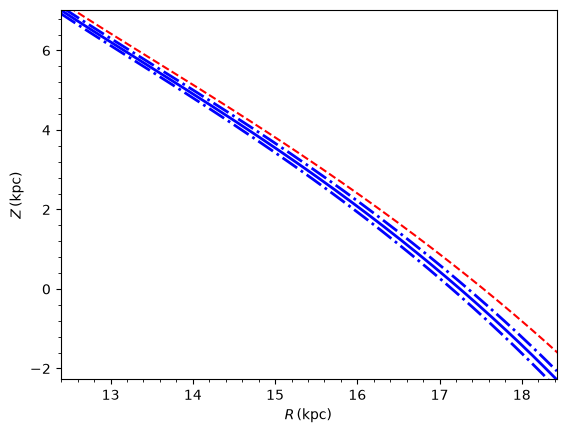

In [4]:
sdf.plotTrack(
    d1="r",
    d2="z",
    interp=True,
    color="b",
    spread=2,
    overplot=False,
    lw=2.0,
    scaleToPhysical=True,
)
sdf.plotProgenitor(
    d1="r", d2="z", color="r", overplot=True, ls="--", scaleToPhysical=True
)
plt.xlabel(r"$R\,(\mathrm{kpc})$")
plt.ylabel(r"$Z\,(\mathrm{kpc})$");

## Unified `StreamTrack` interface

galpy's `StreamTrack` class is a smooth phase-space track container that's
shared across all stream DFs. `streamspraydf` returns one from
`streamspraydf.streamTrack()` (fit to sampled particles); `streamdf` returns the
same kind of object from `streamdf.streamTrack()`, built directly from the
analytically computed action-angle track — no particle fitting required.

The `StreamTrack` exposes a richer accessor set than `plotTrack`: sky / Galactic /
custom-frame coordinates with proper-motion accessors, plus a `cov(basis=...)`
method that returns the 6×6 phase-space covariance in any of `galcenrect`,
`galcencyl`, `sky`, `galsky`, or `customsky` bases via analytical Jacobian
transforms.

In [5]:
track = sdf.streamTrack()
print("type:", type(track).__name__)

# Sample accessors at five tps spanning the stream (LB axes in deg / kpc / km/s / mas/yr).
tps = numpy.linspace(0.0, sdf._deltaAngleTrack * 0.9, 5)
print("ll   (deg) :", track.ll(tps, use_physical=False))
print("bb   (deg) :", track.bb(tps, use_physical=False))
print("dist (kpc) :", track.dist(tps, use_physical=False))
print("vlos (km/s):", track.vlos(tps, use_physical=False))

type: StreamTrack
ll   (deg) : [160.96266863 200.33106012 221.71397966 234.64878143 244.02404764]
bb   (deg) : [56.81288692 41.40803055 21.00716228  5.1057252  -5.8136726 ]
dist (kpc) : [ 8.34973129  7.92760554  8.89590065 10.76034701 12.98834319]
vlos (km/s): [-117.92739814   85.75094286  255.28989604  342.54550621  374.56841591]


In [6]:
# 6x6 covariance in the (l, b, dist, pmll, pmbb, vlos) Galactic-sky basis at one tp,
# in physical units (deg / kpc / mas/yr / km/s). With ``use_physical=True`` the
# Jacobian is run against the stored ``ro=8 kpc`` and ``vo=220 km/s``.
C = track.cov(0.5, basis="galsky", use_physical=True)
sigmas = numpy.sqrt(numpy.diag(C))
for name, unit, s in zip(
    ["ll", "bb", "dist", "pmll", "pmbb", "vlos"],
    ["deg", "deg", "kpc", "mas/yr", "mas/yr", "km/s"],
    sigmas,
):
    print(f"sigma({name}) = {s:.3g} {unit}")

sigma(ll) = 0.465 deg
sigma(bb) = 0.299 deg
sigma(dist) = 0.0351 kpc
sigma(pmll) = 0.0365 mas/yr
sigma(pmbb) = 0.0209 mas/yr
sigma(vlos) = 1.2 km/s


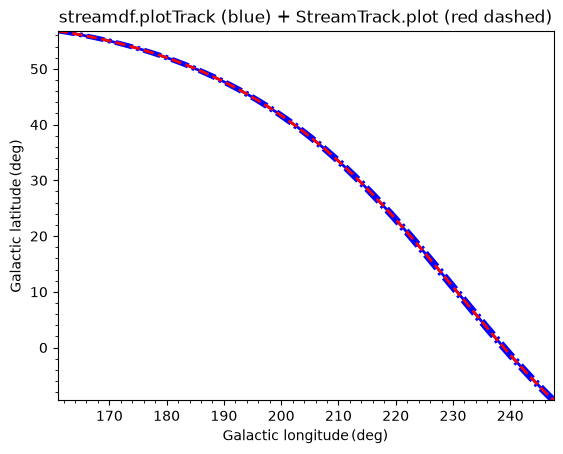

In [7]:
# StreamTrack.plot draws the same kind of figure as streamdf.plotTrack and
# accepts every accessor name as an axis label, including sky bases. Overlay
# both on a single set of axes for comparison.
sdf.plotTrack(d1="ll", d2="bb", spread=1, color="b", lw=2.0)
track.plot(d1="ll", d2="bb", spread=1, color="r", ls="--", lw=2.0)
plt.title("streamdf.plotTrack (blue) + StreamTrack.plot (red dashed)");

The `custom_sky_transform` argument to `streamdf` (a 3×3 rotation from equatorial
coordinates to a custom $(\phi_1, \phi_2)$ sky frame) is forwarded to the
`StreamTrack`, enabling its `phi1`, `phi2`, `pmphi1`, and `pmphi2` accessors. A
convenience helper, `Orbit.align_to_orbit`, builds a rotation matrix that aligns
$\phi_1$ with the progenitor's track.

For sky covariance bands, the cov attached to the streamTrack is the **local**
perpendicular cov (parallel-angle variance = `sigangledAngle**2`), matching the
streamspraydf streamTrack convention. The legacy `_allErrCovsXY` keeps its
likelihood-marginal semantics (parallel-angle variance = 1 rad², needed by
`gaussApprox`) and is what `plotTrack(spread=...)` uses via a 2D minor-eigenvalue
projection. Both pipelines agree exactly at the chunk grid and report the same
perpendicular width; between chunks the eigen-slerp interpolation
(`plotTrack`) and entry-wise linear interpolation (`StreamTrack.plot`) can
differ at the percent level.

## Stream length and width

We can compute the stream length (the angular extent along the stream)
and the width (the spread perpendicular to the stream track).

In [8]:
print("Stream length (radians):", sdf.length(ang=True))
print("Stream length (physical kpc):", sdf.length(phys=True))

Stream length (radians): 93.48285485852354
Stream length (physical kpc): 12.311511040223106


## Sample from the stream

We can draw random samples of stars from the stream distribution function.

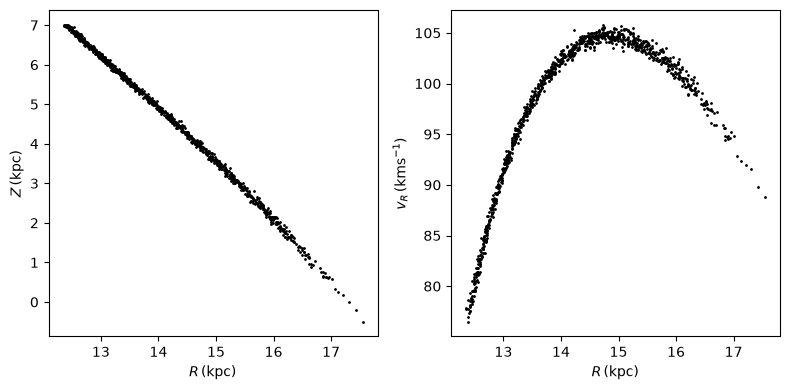

In [9]:
numpy.random.seed(1)
RvR = sdf.sample(n=1000)
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.plot(RvR[0] * 8.0, RvR[3] * 8.0, "k.", ms=2)
plt.xlabel(r"$R\,(\mathrm{kpc})$")
plt.ylabel(r"$Z\,(\mathrm{kpc})$")
plt.subplot(1, 2, 2)
plt.plot(RvR[0] * 8.0, RvR[1] * 220.0, "k.", ms=2)
plt.xlabel(r"$R\,(\mathrm{kpc})$")
plt.ylabel(r"$v_R\,(\mathrm{km s}^{-1})$")
plt.tight_layout();

## Predict observables with callMarg

`streamdf` can also compute marginalized predictions for observables.
For example, the predicted distribution of distance at a given angle
along the stream, marginalizing over all other phase-space dimensions.
Dimensions set to `None` are marginalized over.

For plotting these marginalized distributions, it is useful to start with
a Gaussian approximation to the result, which can be obtained using the `gaussianApprox` method. This gives us a mean and covariance for the distribution of observables at each point along the stream, which we can use to set the range and scale of our plots. We can then use `callMarg` to compute the actual marginalized distribution and compare it to the Gaussian approximation:

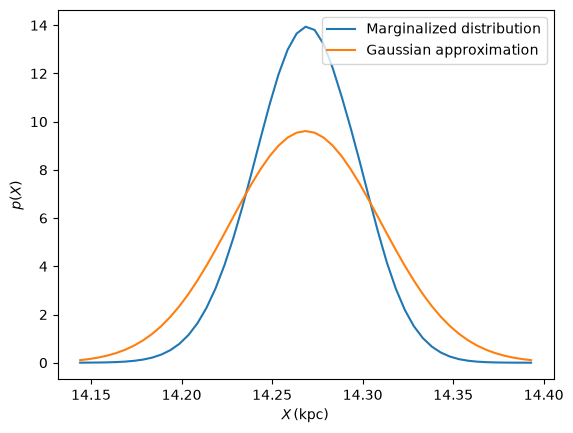

In [10]:
meanp, varp = sdf.gaussApprox([None, None, 2.0 / 8.0, None, None, None])
xs = numpy.linspace(
    meanp[0] - 3 * numpy.sqrt(varp[0, 0]), meanp[0] + 3 * numpy.sqrt(varp[0, 0]), 51
)
logps = numpy.array([sdf.callMarg([x, None, 2.0 / 8.0, None, None, None]) for x in xs])
ps = numpy.exp(logps)
ps /= numpy.sum(ps) * (xs[1] - xs[0]) * 8.0
plt.plot(xs * 8.0, ps, label="Marginalized distribution")
plt.plot(
    xs * 8.0,
    1.0
    / numpy.sqrt(2.0 * numpy.pi)
    / numpy.sqrt(varp[0, 0])
    / 8.0
    * numpy.exp(-0.5 * (xs - meanp[0]) ** 2.0 / varp[0, 0]),
    label="Gaussian approximation",
)
plt.xlabel(r"$X\,(\mathrm{kpc})$")
plt.ylabel(r"$p(X)$")
plt.legend();

## Checking track accuracy

To verify that the stream track is calculated accurately, use
`plotCompareTrackAAModel` (the track in frequency-angle space should
match the points calculated from the track's phase-space positions).
Also check the eigenvalue ratio and misalignment:

Frequency eigenvalue ratio (isotropic): 34.449740915155836
Frequency eigenvalue ratio (model): 29.625569108953943
Misalignment (rad): -0.008644139914229854


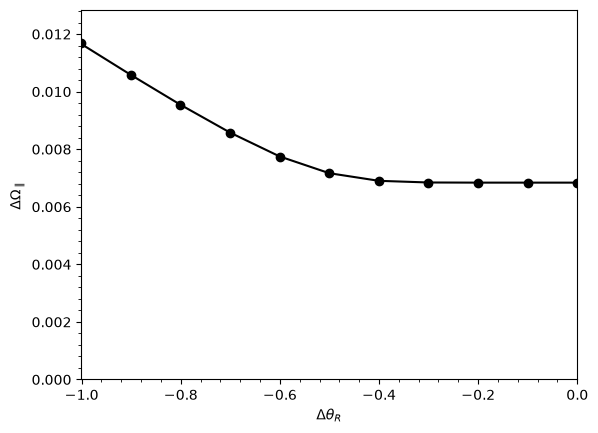

In [11]:
# Eigenvalue ratio: a large value means a ~1D stream will form
print("Frequency eigenvalue ratio (isotropic):", sdf.freqEigvalRatio(isotropic=True))
print("Frequency eigenvalue ratio (model):", sdf.freqEigvalRatio())

# Misalignment between progenitor frequency vector and mean stream frequency
print("Misalignment (rad):", sdf.misalignment())

sdf.plotCompareTrackAAModel()

## Mock stream data in observable coordinates

We can generate mock data directly in Galactic coordinates (l, b, distance,
proper motions, line-of-sight velocity):

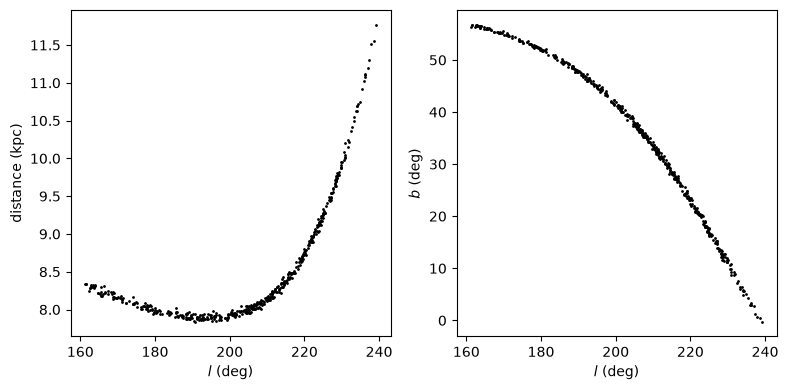

In [12]:
numpy.random.seed(1)
# Sample in (l, b, dist, pmll, pmbb, vlos) coordinates
lb = sdf.sample(n=500, lb=True)
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.plot(lb[0], lb[2], "k.", ms=2)
plt.xlabel(r"$l$ (deg)")
plt.ylabel(r"distance (kpc)")
plt.subplot(1, 2, 2)
plt.plot(lb[0], lb[1], "k.", ms=2)
plt.xlabel(r"$l$ (deg)")
plt.ylabel(r"$b$ (deg)")
plt.tight_layout();

## Frequency-angle sampling

We can also sample in frequency-angle coordinates, which returns frequency
vectors, angle vectors, and stripping times:

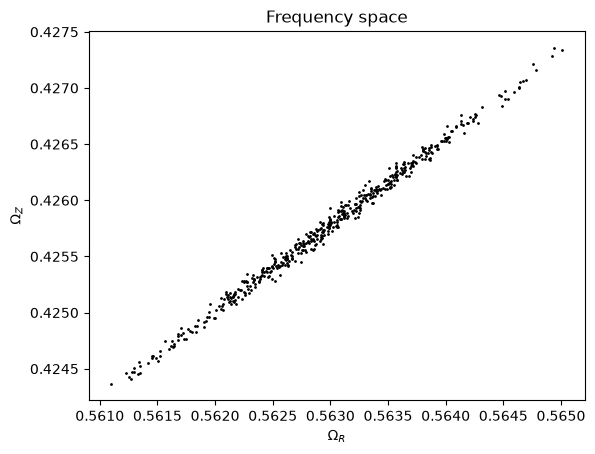

In [13]:
numpy.random.seed(1)
# Returns (frequencies [3,N], angles [3,N], stripping_time [N])
mockaA = sdf.sample(n=500, returnaAdt=True)
plt.plot(mockaA[0][0], mockaA[0][2], "k.", ms=2)
plt.xlabel(r"$\Omega_R$")
plt.ylabel(r"$\Omega_Z$")
plt.title("Frequency space");

## Full PDF evaluation

The stream PDF (log probability of a phase-space position) can be evaluated directly:

In [14]:
# Evaluate log PDF at the progenitor location
logpdf = sdf(obs.R(), obs.vR(), obs.vT(), obs.z(), obs.vz(), obs.phi())
print("log PDF at progenitor:", logpdf)

# Evaluate at a point near the stream track (small offset in R)
logpdf_near = sdf(
    obs.R() + 0.01, obs.vR(), obs.vT(), obs.z(), obs.vz(), obs.phi() + 0.05
)
print("log PDF near stream track:", logpdf_near)

# A point far from the stream has -inf probability
logpdf_far = sdf(obs.R() - 0.5, obs.vR(), obs.vT(), obs.z() + 0.5, obs.vz(), obs.phi())
print("log PDF far from stream:", logpdf_far)

log PDF at progenitor: [-8.49075355]
log PDF near stream track: [-152.00755895]
log PDF far from stream: [-inf]


## Modeling gaps in streams: streamgapdf

galpy also contains `streamgapdf`, a subclass of `streamdf` for modeling the
effect of impacts from dark-matter subhalos on streams (see [Sanders, Bovy, & Erkal
2016](https://ui.adsabs.harvard.edu/abs/2016MNRAS.457.3817S/abstract)). It shares many methods with `streamdf` but additionally takes parameters
specifying the impact (impact parameter, velocity, location, time, and subhalo
mass/structure). This allows one to model gaps and density variations along
streams caused by subhalo encounters.

Let's set up a basic `streamgapdf` example following the Sanders et al. paper:

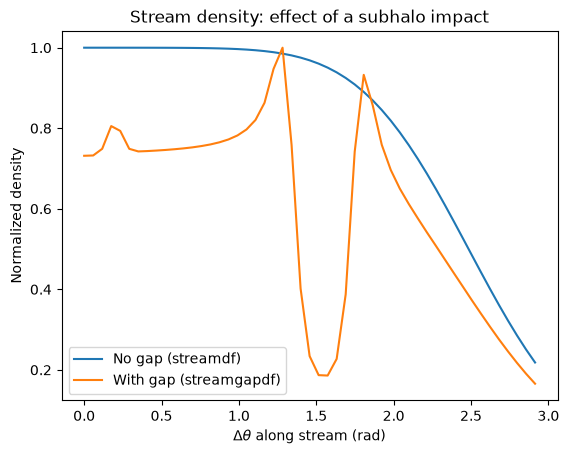

In [15]:
from galpy.df import streamgapdf

lp = LogarithmicHaloPotential(normalize=1.0, q=0.9)
aAI = actionAngleIsochroneApprox(pot=lp, b=0.8)
prog_unp_peri = Orbit(
    [
        2.6556151742081835,
        0.2183747276300308,
        0.67876510797240575,
        -2.0143395648974671,
        -0.3273737682604374,
        0.24218273922966019,
    ]
)
sigv = 0.365 * (10.0 / 2.0) ** (1.0 / 3.0) * units.km / units.s
tdisrupt = 10.88 * units.Gyr

# Impact parameters: time of impact, location along stream, impact parameter,
# velocity of the subhalo, and subhalo mass (as a Plummer sphere)
GM = 10.0**8.0 * units.Msun
rs = 0.625 * units.kpc
impactb = 0.0
subhalovel = numpy.array([6.82200571, 132.7700529, 149.4174464]) * units.km / units.s
timpact = 0.88 * units.Gyr
impact_angle = -1.34

sdf = streamdf(
    sigv,
    progenitor=prog_unp_peri,
    pot=lp,
    aA=aAI,
    leading=False,
    nTrackChunks=26,
    nTrackIterations=1,
    sigMeanOffset=4.5,
    tdisrupt=tdisrupt,
)

sdf_gap = streamgapdf(
    sigv,
    progenitor=prog_unp_peri,
    pot=lp,
    aA=aAI,
    leading=False,
    nTrackChunks=26,
    nTrackIterations=1,
    sigMeanOffset=4.5,
    tdisrupt=tdisrupt,
    impactb=impactb,
    subhalovel=subhalovel,
    timpact=timpact,
    impact_angle=impact_angle,
    GM=GM,
    rs=rs,
)

# Compare density along the stream with and without the gap
stream_length_deg = sdf.length(ang=True)
dangle = numpy.linspace(0.0, numpy.radians(stream_length_deg), 51)
dens_nogap = numpy.array([sdf.density_par(da) for da in dangle])
dens_gap = numpy.array([sdf_gap.density_par(da) for da in dangle])

plt.plot(dangle, dens_nogap / numpy.max(dens_nogap), label="No gap (streamdf)")
plt.plot(dangle, dens_gap / numpy.max(dens_gap), label="With gap (streamgapdf)")
plt.xlabel(r"$\Delta\theta$ along stream (rad)")
plt.ylabel("Normalized density")
plt.legend()
plt.title("Stream density: effect of a subhalo impact");